In [372]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import yfinance as yf

In [373]:
btc=yf.download("BTC-USD",start="2018-01-01",end="2022-12-01")
btc

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2018-01-01,13657.200195,14112.200195,13154.700195,14112.200195,10291200000
2018-01-02,14982.099609,15444.599609,13163.599609,13625.000000,16846600192
2018-01-03,15201.000000,15572.799805,14844.500000,14978.200195,16871900160
2018-01-04,15599.200195,15739.700195,14522.200195,15270.700195,21783199744
2018-01-05,17429.500000,17705.199219,15202.799805,15477.200195,23840899072
...,...,...,...,...,...
2022-11-26,16464.281250,16666.863281,16416.228516,16521.576172,18000008764
2022-11-27,16444.626953,16594.406250,16437.025391,16463.882812,20443898509


In [374]:
def df_update(btc):
    btc.reset_index(inplace=True)
    btc.columns = btc.columns.get_level_values(0)
    
    
    btc["EMA_14"]=btc["Close"].ewm(span=14,adjust=False).mean()
    btc["buy_band"]=btc["EMA_14"]+btc["High"]-btc["Low"]
    btc["sell_band"]=btc["EMA_14"]-btc["High"]+btc["Low"]
    
    #calculating ATR
    high_low=btc["High"]-btc["Low"]
    high_close=abs(btc["High"]-btc["Close"].shift(1))
    high_close=abs(btc["Low"]-btc["Close"].shift(1))
    tr=[max(values) for values in zip(high_low,high_close,high_close)]
    btc["true_range"]=tr
    btc["ATR"]=btc["true_range"].ewm(span=14,adjust=False).mean()
    k=1.5
    btc["atr_buy_band"]=btc["EMA_14"]+btc["ATR"]*k
    btc["atr_sell_band"]=btc["EMA_14"]-btc["ATR"]*k

df_update(btc)

In [375]:
btc

Price,Date,Close,High,Low,Open,Volume,EMA_14,buy_band,sell_band,true_range,ATR,atr_buy_band,atr_sell_band
0,2018-01-01,13657.200195,14112.200195,13154.700195,14112.200195,10291200000,13657.200195,14614.700195,12699.700195,957.500000,957.500000,15093.450195,12220.950195
1,2018-01-02,14982.099609,15444.599609,13163.599609,13625.000000,16846600192,13833.853451,16114.853451,11552.853451,2281.000000,1133.966667,15534.803451,12132.903451
2,2018-01-03,15201.000000,15572.799805,14844.500000,14978.200195,16871900160,14016.139657,14744.439462,13287.839852,728.299805,1079.877752,15635.956285,12396.323030
3,2018-01-04,15599.200195,15739.700195,14522.200195,15270.700195,21783199744,14227.214396,15444.714396,13009.714396,1217.500000,1098.227385,15874.555473,12579.873318
4,2018-01-05,17429.500000,17705.199219,15202.799805,15477.200195,23840899072,14654.185809,17156.585224,12151.786395,2502.399414,1285.450322,16582.361293,12726.010326
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1790,2022-11-26,16464.281250,16666.863281,16416.228516,16521.576172,18000008764,16783.701442,17034.336207,16533.066676,250.634766,508.533944,17546.502358,16020.900526
1791,2022-11-27,16444.626953,16594.406250,16437.025391,16463.882812,20443898509,16738.491510,16895.872369,16581.110651,157.380859,461.713533,17431.061809,16045.921211
1792,2022-11-28,16217.322266,16482.933594,16054.530273,16440.222656,27743025156,16669.002277,17097.405598,16240.598957,428.403320,457.272171,17354.910534,15983.094021
1793,2022-11-29,16444.982422,16522.257812,16139.396484,16217.639648,23581685468,16639.132963,17021.994291,16256.271635,382.861328,447.350725,17310.159051,15968.106875


In [376]:
def strategy(df):
    signal=[0]
    for i in range(1,len(df)):
        if df["Close"].iloc[i]>df["EMA_14"].iloc[i] and df.loc[i,"Close"]>df.loc[i,"buy_band"] and df.loc[i,"Close"]>df.loc[i,"atr_buy_band"]:
            signal.append(1)
        elif df["Close"].iloc[i]<df["EMA_14"].iloc[i] and df.loc[i,"Close"]<df.loc[i,"sell_band"] and df.loc[i,"Close"]<df.loc[i,"atr_sell_band"]:
            signal.append(-1)
        else:
            signal.append(0)
    df["Signal"]=signal
strategy(btc)

In [377]:
def signal_correction(df):
    corrected_signal=[0]
    pos=[0]
    for i in range(1, len(df)):
        current_signal = df.loc[i, "Signal"]
        prev_pos = pos[i-1]
    
        if current_signal == 1:
            if prev_pos == 0:
                corrected_signal.append(1)
                pos.append(1)
            elif prev_pos == 1:
                corrected_signal.append(0)
                pos.append(1)
            elif prev_pos == -1:
                corrected_signal.append(1)
                pos.append(0)  
        elif current_signal == -1:
            if prev_pos == 0:
                corrected_signal.append(-1)
                pos.append(-1)
            elif prev_pos == -1:
                corrected_signal.append(0)
                pos.append(-1)
            elif prev_pos == 1:
                corrected_signal.append(-1)
                pos.append(0)  
        else:
            corrected_signal.append(0)
            pos.append(prev_pos)

    df["Signal"] = corrected_signal

signal_correction(btc)

In [378]:
def backtesting(df,signal,initial_capital):
    trade_idx=[]
    opening_trade_idx=[]
    closing_trade_idx=[]
    entry_date=[]
    exit_date=[]
    pos=[]
    type_of_trade=[]
    #stop_loss=0.1

    prev_pos=0
    current_signal=0
    for i in range(len(df)):
        if df.loc[i,signal]==1 or df.loc[i,signal]==-1:
            trade_idx.append(i)
        
        current_signal=df.loc[i,signal]
        
        if current_signal==1:
            if prev_pos==0:
                pos.append(1)
                opening_trade_idx.append(i)
                type_of_trade.append("long")
                entry_date.append(df.loc[i,"Date"])
            elif prev_pos==1:
                pos.append(1)
            elif prev_pos==-1:
                pos.append(0)
                closing_trade_idx.append(i)
                exit_date.append(df.loc[i,"Date"])
        elif current_signal==-1:
            if prev_pos==0:
                pos.append(-1)
                opening_trade_idx.append(i)
                type_of_trade.append("short")
                entry_date.append(df.loc[i,"Date"])
            elif prev_pos==1:
                pos.append(0)
                closing_trade_idx.append(i)
                exit_date.append(df.loc[i,"Date"])
            elif prev_pos==-1:
                pos.append(-1)
        else:
            pos.append(prev_pos)

        prev_pos=pos[i]

    #squaring off all positions at the end
    if pos[len(df)-1]==1:
        pos[len(df)-1]=0
        df.loc[len(df)-1,signal]=-1
        closing_trade_idx.append(len(df)-1)
        exit_date.append(df.loc[len(df)-1,"Date"])
    elif pos[len(df)-1]==-1:
        pos[len(df)-1]=0
        df.loc[len(df)-1,signal]=1
        closing_trade_idx.append(len(df)-1)
        exit_date.append(df.loc[len(df)-1,"Date"])


    #implementing ATR based stop loss and dynamic exit for long and short trades resp.
    
    multiplier=3
    for k in range(len(opening_trade_idx)):          
        if type_of_trade[k]=="long":
            entry_row   = opening_trade_idx[k]
            planned_out = closing_trade_idx[k]
        
            entry_price = df.loc[entry_row, "Close"]
            #sl = (1 - stop_loss) * entry_price # long-side stop
            sl= entry_price-(multiplier*df.loc[entry_row,"ATR"])
        
            for j in range(entry_row, planned_out):
                if df.loc[j, "Close"] < sl:              
                    closing_trade_idx[k] = j           # actual exit index
                    df.loc[j, signal] = -1             # mark stop-loss exit
                    df.loc[planned_out,signal]=0       #turning the actual planned out signal to 0 so that is still a strictly one position at a time
                    break
    
    
    for k in range(len(opening_trade_idx)):          
        if type_of_trade[k]=="short":
            entry_row   = opening_trade_idx[k]
            planned_out = closing_trade_idx[k]
        
            entry_price = df.loc[entry_row, "Close"]
            #sl = (1 - stop_loss) * entry_price # long-side stop
            de= entry_price+(multiplier*df.loc[entry_row,"ATR"])
        
            for j in range(entry_row, planned_out):
                if df.loc[j, "Close"] > de:              
                    closing_trade_idx[k] = j          # actual exit index
                    df.loc[j, signal] = 1             # mark stop-loss exit
                    df.loc[planned_out,signal]=0      #turning the actual planned out signal to 0 so that is still a strictly one position at a time
                    break
    
    
    no_of_shares=[]
    capital=initial_capital
    portfolio=[]
    shares=0
    
    
    for i in range(len(df)):
        price=df.loc[i,"Close"]
        #long trade
        if df.loc[i,signal]==1 and pos[i-1]==0 and capital>price :
            shares=int(capital/price)
            capital-=shares*price
            #trades_idx_1.append(i)
            #type_of_trade1.append("long")
        elif df.loc[i,signal]==-1 and pos[i-1]==1 and shares>0:
            capital+=shares*price
            shares=0
            #trades_idx_1.append(i)
            #type_of_trade1.append("long close")
        #short trade    
        elif df.loc[i,signal]==-1 and pos[i-1]==0 and capital>price:
            shares=-int(capital/price)
            capital-=shares*price
            #trades_idx_1.append(i)
            #type_of_trade1.append("short")
        elif df.loc[i,signal]==1 and pos[i-1]==-1 and shares<0:
            capital+=shares*price
            shares=0
            #trades_idx_1.append(i)
            #type_of_trade1.append("short close")
        portfolio_value=shares*price+capital
        portfolio.append(portfolio_value)
        no_of_shares.append(shares)

    #print((opening_trade_idx))
    #print((closing_trade_idx))
    #print(len(type_of_trade))
    #print(pos)
    #print(type_of_trade)
    #print(df.loc[len(df)-1,signal])
    
    
    returns=[]
    for i in range(len(opening_trade_idx)):
        if type_of_trade[i]=="long":
            returns.append((df.loc[closing_trade_idx[i],"Close"]-df.loc[opening_trade_idx[i],"Close"])*100/df.loc[opening_trade_idx[i],"Close"])
        else:
            returns.append(-(df.loc[closing_trade_idx[i],"Close"]-df.loc[opening_trade_idx[i],"Close"])*100/df.loc[opening_trade_idx[i],"Close"])
        
        
    
    trade_wise_df=pd.DataFrame({"Entry Index": opening_trade_idx,"Exit Index":closing_trade_idx,"Entry Date":entry_date,"Exit Date":exit_date,"Type of Trade":type_of_trade})
    trade_wise_df["No of stock traded"]=[no_of_shares[i]-no_of_shares[i-1] for i in opening_trade_idx]
    trade_wise_df["Return for trade in %"]=returns
    trade_wise_df["Trade Duration"]=trade_wise_df["Exit Index"]-trade_wise_df["Entry Index"]
    #np.where(df_1["Type of trade"]=='long',(returns,-returns)
    
    daily_df=pd.DataFrame({"Portfolio Value":portfolio,"No. of Stock":no_of_shares})
    daily_df["Profit from initial Capital"]=(daily_df["Portfolio Value"]-initial_capital)*100/initial_capital
    daily_df["Daily Returns in %"]=(daily_df["Portfolio Value"].pct_change())*100
    return trade_wise_df,daily_df

trade_wise_btc,daily_btc=backtesting(btc,"Signal",100000)

In [379]:
pd.set_option("display.max_rows",None)

In [380]:
pd.reset_option("display.max_rows")

In [381]:
trade_wise_btc

,Entry Index,Exit Index,Entry Date,Exit Date,Type of Trade,No of stock traded,Return for trade in %,Trade Duration
0,4,10,2018-01-05,2018-01-17,long,5,-23.085574,6
1,31,47,2018-02-01,2018-02-17,short,-8,-21.178253,16
2,49,66,2018-02-19,2018-03-08,long,5,-16.305044,17
3,68,104,2018-03-10,2018-04-15,short,-6,6.055602,36
4,109,130,2018-04-20,2018-05-11,long,6,-4.570966,21
5,136,197,2018-05-17,2018-07-17,short,-6,9.553363,61
6,198,215,2018-07-18,2018-08-04,long,8,-4.584721,17
7,216,239,2018-08-05,2018-08-28,short,-8,-0.393293,23
8,243,248,2018-09-01,2018-09-06,long,8,-9.231989,5
9,249,353,2018-09-07,2018-12-20,short,-8,36.069325,104


In [382]:
daily_btc

,Portfolio Value,No. of Stock,Profit from initial Capital,Daily Returns in %
0,1.000000e+05,0,0.000000,NaN
1,1.000000e+05,0,0.000000,0.000000
2,1.000000e+05,0,0.000000,0.000000
3,1.000000e+05,0,0.000000,0.000000
4,1.000000e+05,5,0.000000,0.000000
...,...,...,...,...
1790,1.383842e+06,-78,1283.842313,0.325495
1791,1.385375e+06,-78,1285.375348,0.110781
1792,1.403105e+06,-78,1303.105114,1.279781
1793,1.385348e+06,-78,1285.347622,-1.265585


In [383]:
def plot_buy_sell(df,trade_wise_df):
    import plotly.graph_objects as go

    fig = go.Figure()
    
    # Line plot for stock price
    fig.add_trace(go.Scatter(
        x=df["Date"],
        y=df["Close"],
        mode='lines',
        name='Close Price',
        line=dict(color='blue')
    ))
    

    long_trades = trade_wise_df[trade_wise_df["Type of Trade"] == "long"]
    short_trades = trade_wise_df[trade_wise_df["Type of Trade"] == "short"]
    
    # Long Entry: green triangle-up
    fig.add_trace(go.Scatter(
        x=df.loc[long_trades["Entry Index"], "Date"],
        y=df.loc[long_trades["Entry Index"], "Close"],
        mode='markers',
        marker=dict(symbol='triangle-up', color='green', size=12),
        name='Long Entry'
    ))
    
    # Short Entry: red triangle-down
    fig.add_trace(go.Scatter(
        x=df.loc[short_trades["Entry Index"], "Date"],
        y=df.loc[short_trades["Entry Index"], "Close"],
        mode='markers',
        marker=dict(symbol='triangle-down', color='red', size=12),
        name='Short Entry'
    ))
    
    # Long Exit: red triangle-down
    fig.add_trace(go.Scatter(
        x=df.loc[long_trades["Exit Index"], "Date"],
        y=df.loc[long_trades["Exit Index"], "Close"],
        mode='markers',
        marker=dict(symbol='triangle-down', color='red', size=10),
        name='Long Exit'
    ))
    
    # Short Exit: green triangle-up
    fig.add_trace(go.Scatter(
        x=df.loc[short_trades["Exit Index"], "Date"],
        y=df.loc[short_trades["Exit Index"], "Close"],
        mode='markers',
        marker=dict(symbol='triangle-up', color='green', size=10),
        name='Short Exit'
    ))
    
    fig.update_layout(title="Trade Entries & Exits on Stock Price")
    fig.show()

def plot_portfolio(df,daily_df):
    fig=px.line(x=df["Date"],y=daily_df["Portfolio Value"])
    fig.show()


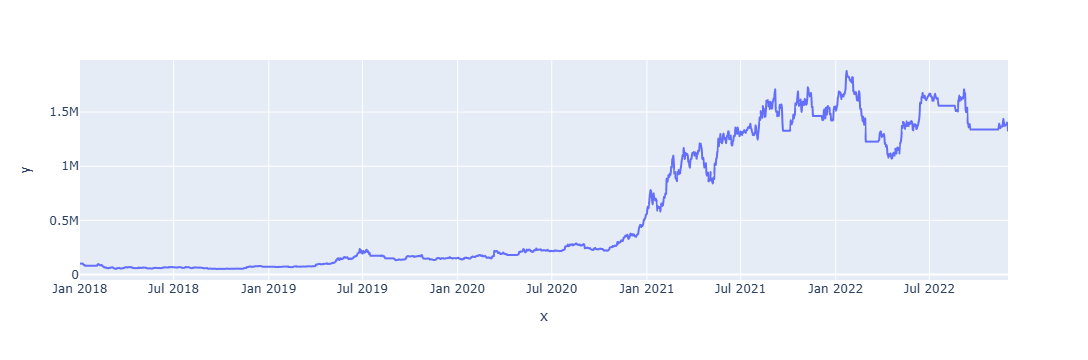

In [384]:
plot_portfolio(btc,daily_btc)

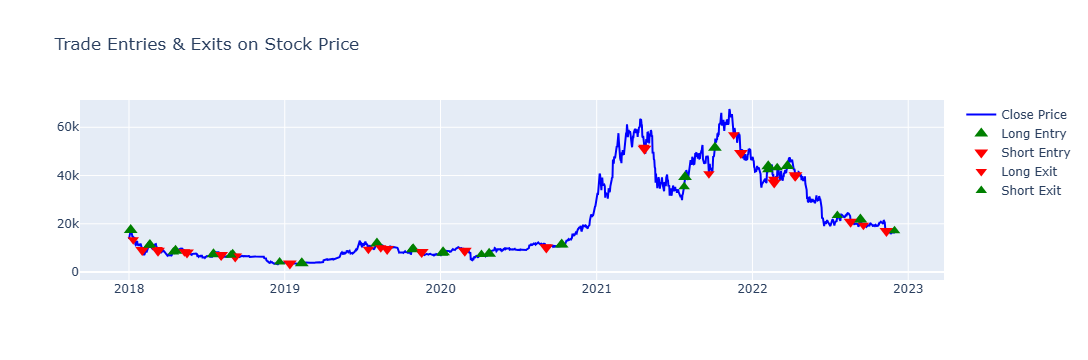

In [385]:
plot_buy_sell(btc,trade_wise_btc)

In [386]:
def benchmark_metrics(df,trade_wise_df,daily_df):
    benchmark_return=((df.loc[len(df)-1,"Close"]-df.loc[0,"Close"])*100)/df.loc[0,"Close"]
    gross_profit=daily_df.loc[len(daily_df)-1,"Profit from initial Capital"]

    total_trades=len(trade_wise_df)
    winning_trades= (trade_wise_df["Return for trade in %"]>0).sum()
    losing_trades=total_trades-winning_trades
    max_holding_time=trade_wise_df["Trade Duration"].max()
    avg_holding_time=trade_wise_df["Trade Duration"].mean()

    #to calculate max drawdown
    drawdown=[]
    for i in range(len(trade_wise_df)):
        entry_idx=trade_wise_df.loc[i,"Entry Index"]
        exit_idx=trade_wise_df.loc[i,"Exit Index"]
        initial_value=daily_df.loc[entry_idx,"Portfolio Value"]

        max_drawdown=0
        temp1=initial_value
        for j in range(entry_idx+1,exit_idx+1):
            temp1=max(temp1,daily_df.loc[j,"Portfolio Value"])
            drawdown_value = (temp1 - daily_df.loc[j,"Portfolio Value"]) / temp1
            max_drawdown=max(max_drawdown,drawdown_value)
        drawdown.append(max_drawdown)

    mean_return=trade_wise_df["Return for trade in %"].mean()
    std_return=trade_wise_df["Return for trade in %"].std()
    rfr=0
    sharpe=(mean_return-rfr)*np.sqrt(252)/std_return
    
    mean_return_daily=daily_df["Daily Returns in %"].mean()
    std_return_daily=daily_df["Daily Returns in %"].std()
    sharpe_daily=mean_return_daily-rfr*np.sqrt(252)/std_return_daily

    
    
    

    print("Benchmark Return: "+str(benchmark_return)+" %")
    print("Gross Profit: "+str(gross_profit)+" %")
    print("Max Holding Time: "+str(max_holding_time))
    print("Average Holding Time: "+str(avg_holding_time))
    print("Total Trades: "+str(total_trades))
    print("Winning Trades: "+str(winning_trades))
    print("Losing Trades: "+str(losing_trades))
    print("Max Drawdown: "+str(100*max(drawdown))+" %")
    print("Sharpe Ratio: "+str(sharpe))
    #print("Sharpe Ratio daily: "+str(sharpe_daily))

benchmark_metrics(btc,trade_wise_btc,daily_btc)

Benchmark Return: 25.710732512676284 %
Gross Profit: 1228.9080708007812 %
Max Holding Time: 193
Average Holding Time: 47.28125
Total Trades: 32
Winning Trades: 14
Losing Trades: 18
Max Drawdown: 34.07601895848972 %
Sharpe Ratio: 4.010348775309886
